In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns
import matplotlib.dates as mdates
from prophet import Prophet
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.gridspec as gridspec
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Statsmodels
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson, jarque_bera

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import shapiro, normaltest

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# One

In [2]:
data_path = "data/raw"
vaccine_cover_path = f"{data_path}/Couvertures vaccinales des adolescents et adultes/"
iqivia_path = f"{data_path}/IQVIA : distribution de vaccins + actes de vaccination en pharmacie/"
patients_path = f"{data_path}/Passage des patients/"

In [3]:
files = glob.glob(f"{vaccine_cover_path}*.csv")

print(files)


['data/raw/Couvertures vaccinales des adolescents et adultes/couvertures-vaccinales-des-adolescents-et-adultes-depuis-2011-france.csv', 'data/raw/Couvertures vaccinales des adolescents et adultes/couvertures-vaccinales-des-adolescent-et-adultes-departement.csv', 'data/raw/Couvertures vaccinales des adolescents et adultes/couvertures-vaccinales-des-adolescents-et-adultes-depuis-2011-region.csv']


In [4]:
vaccine_cover_dep = pd.read_csv(files[0])
display(vaccine_cover_dep, vaccine_cover_dep.shape)

,Année,HPV filles 1 dose à 15 ans,HPV filles 2 doses à 16 ans,HPV garçons 1 dose à 15 ans,HPV garçons 2 doses à 16 ans,Méningocoque C 10-14 ans,Méningocoque C 15-19 ans,Méningocoque C 20-24 ans,Grippe moins de 65 ans à risque,Grippe 65 ans et plus,Grippe 65-74 ans,Grippe 75 ans et plus,Covid-19 65 ans et plus,Grippe résidents en Ehpad,Grippe professionnels en Ehpad,Covid-19 résidents en Ehpad,Covid-19 professionnels en Ehpad
0,2011,28.7,25.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020,40.7,32.7,NaN,NaN,57.7,37.8,NaN,38.7,59.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012,20.9,22.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013,19.8,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,20.6,13.2,NaN,NaN,31.4,22.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019,34.9,27.9,NaN,NaN,52.9,34.8,NaN,31.0,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2022,47.0,41.5,12.8,8.5,68.2,43.8,NaN,31.6,56.2,50.7,62.2,NaN,NaN,NaN,NaN,NaN
7,2023,54.6,44.7,25.9,15.8,71.9,48.0,NaN,25.4,54.0,46.6,61.9,30.2,NaN,NaN,NaN,NaN
8,2024,58.4,48.0,36.9,24.5,73.6,53.6,33.6,25.3,53.7,46.7,60.7,NaN,NaN,NaN,NaN,NaN
9,2014,19.4,15.7,NaN,NaN,28.7,20.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(14, 17)

In [5]:
vaccine_cover_dep = pd.read_csv(files[1])
display(vaccine_cover_dep, vaccine_cover_dep.shape)

,Année,Département Code,Département,HPV filles 1 dose à 15 ans,HPV filles 2 doses à 16 ans,HPV garçons 1 dose à 15 ans,HPV garçons 2 doses à 16 ans,Méningocoque C 10-14 ans,Méningocoque C 15-19 ans,Méningocoque C 20-24 ans,Grippe moins de 65 ans à risque,Grippe 65 ans et plus,Grippe 65-74 ans,Grippe 75 ans et plus,Covid-19 65 ans et plus,Région,Région Code
0,2011,04,NaN,24.6,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,05,NaN,22.3,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,09,NaN,25.6,21.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012,10,Aube,26.2,26.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Grand Est,44.0
4,2014,10,Aube,25.5,20.4,NaN,NaN,35.0,26.2,NaN,NaN,NaN,NaN,NaN,NaN,Grand Est,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1409,2024,87,Haute-Vienne,67.7,56.8,42.0,30.3,80.6,NaN,NaN,29.0,57.1,50.8,63.0,NaN,Nouvelle Aquitaine,75.0
1410,2024,91,Essonne,49.6,41.2,33.1,21.4,73.6,54.2,32.6,23.0,55.5,47.7,63.4,NaN,Île-de-France,11.0
1411,2024,93,Seine-Saint-Denis,31.7,22.3,16.9,9.3,73.1,58.3,32.8,19.5,43.8,37.6,51.6,NaN,Île-de-France,11.0
1412,2024,95,Val-d'Oise,41.9,33.3,24.3,15.1,77.3,59.1,36.4,20.1,50.8,43.9,58.8,NaN,Île-de-France,11.0


(1414, 17)

In [6]:
vaccine_cover_dep = pd.read_csv(files[2])
display(vaccine_cover_dep, vaccine_cover_dep.shape)

,Année,Région Code,Région,HPV filles 1 dose à 15 ans,HPV filles 2 doses à 16 ans,HPV garçons 1 dose à 15 ans,HPV garçons 2 doses à 16 ans,Méningocoque C 10-14 ans,Méningocoque C 15-19 ans,Méningocoque C 20-24 ans,Grippe moins de 65 ans à risque,Grippe 65 ans et plus,Grippe 65-74 ans,Grippe 75 ans et plus,Covid-19 65 ans et plus,Grippe résidents en Ehpad,Grippe professionnels en Ehpad,Covid-19 résidents en Ehpad,Covid-19 professionnels en Ehpad
0,2011,84,Auvergne et Rhône-Alpes,26.0,24.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,84,Auvergne et Rhône-Alpes,17.2,14.7,NaN,NaN,24.6,17.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,84,Auvergne et Rhône-Alpes,18.6,12.5,NaN,NaN,27.9,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,84,Auvergne et Rhône-Alpes,24.4,20.3,NaN,NaN,35.7,25.5,NaN,29.5,48.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,84,Auvergne et Rhône-Alpes,27.3,22.5,NaN,NaN,41.6,28.5,NaN,29.2,50.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,2011,4,Réunion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
234,2012,4,Réunion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235,2013,4,Réunion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,2016,4,Réunion,12.0,8.4,NaN,NaN,40.7,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(238, 19)

In [7]:
iqivia_files = glob.glob(f"{iqivia_path}/*/*.csv")
campagnes = [file for file in iqivia_files if "campagne" in file]
couvertures = [file for file in iqivia_files if "couverture" in file]
doses = [file for file in iqivia_files if "doses" in file]

In [8]:
campagnes_data = pd.concat([pd.read_csv(file) for file in campagnes])
display(campagnes_data, campagnes_data.shape) 

,campagne,date,variable,valeur,cible
0,2021-2022,2022-02-28,ACTE(VGP),4475890,3823445
1,2021-2022,2022-02-28,DOSES(J07E1),11178955,11915574
2,2021-2022,2022-02-28,UNIVERS,21078,21241
3,2021-2022,2022-02-28,PHARMACIES,16356,15528
4,2021-2022,2022-02-28,POURCENTAGE,78,74
0,2025-2026,2026-02-25,ACTE(VGP),8018556,6627516
1,2025-2026,2026-02-25,DOSES(J07E1),12014015,10926760
2,2025-2026,2026-02-25,UNIVERS,20025,20287
3,2025-2026,2026-02-25,PHARMACIES,18585,17950
4,2025-2026,2026-02-25,POURCENTAGE,93,89


(25, 5)

In [9]:
couverture_data = pd.concat([pd.read_csv(file) for file in couvertures])
display(couverture_data, couverture_data.shape) 

,region,code,variable,groupe,valeur
0,11 - ILE-DE-France,11,ACTE(VGP),moins de 65 ans,204
1,11 - ILE-DE-France,11,DOSES(J07E1),moins de 65 ans,458
2,24 - CENTRE-VAL-DE-LOIRE,24,ACTE(VGP),moins de 65 ans,214
3,24 - CENTRE-VAL-DE-LOIRE,24,DOSES(J07E1),moins de 65 ans,562
4,27 - BOURGOGNE-FRANCHE-COMTE,27,ACTE(VGP),moins de 65 ans,183
...,...,...,...,...,...
27,76 - OCCITANIE,76,DOSES(J07E1),moins de 65 ans,501
28,94 - CORSE,94,ACTE(VGP),65 ans et plus,1553
29,94 - CORSE,94,DOSES(J07E1),65 ans et plus,4487
30,94 - CORSE,94,ACTE(VGP),moins de 65 ans,141


(240, 5)

In [10]:
doses_data = pd.concat([pd.read_csv(file) for file in doses])
display(doses_data, doses_data.shape) 

,campagne,date,jour,variable,groupe,valeur
0,2020-2021,2020-10-13,1,ACTE(VGP),65 ans et plus,296119
1,2020-2021,2020-10-13,1,DOSES(J07E1),65 ans et plus,1685461
2,2020-2021,2020-10-13,1,ACTE(VGP),moins de 65 ans,75969
3,2020-2021,2020-10-13,1,DOSES(J07E1),moins de 65 ans,479784
4,2020-2021,2020-10-14,2,ACTE(VGP),65 ans et plus,242598
...,...,...,...,...,...,...
1083,2024-2025,2025-02-27,136,DOSES(J07E1),moins de 65 ans,702
1084,2024-2025,2025-02-28,137,ACTE(VGP),65 ans et plus,321
1085,2024-2025,2025-02-28,137,DOSES(J07E1),65 ans et plus,693
1086,2024-2025,2025-02-28,137,ACTE(VGP),moins de 65 ans,417


(5384, 6)

In [11]:
grippe_files = glob.glob(f"{patients_path}/*.csv")
print(grippe_files)

['data/raw/Passage des patients/grippe-passages-aux-urgences-et-actes-sos-medecins-france.csv', 'data/raw/Passage des patients/grippe-passages-urgences-et-actes-sos-medecin_reg.csv', 'data/raw/Passage des patients/grippe-passages-aux-urgences-et-actes-sos-medecins-departement.csv']


In [12]:
grippe_files_france = pd.read_csv(grippe_files[0])
display(grippe_files_france, grippe_files_france.shape)

,1er jour de la semaine,Semaine,Classe d'âge,Taux de passages aux urgences pour grippe,Taux d'hospitalisations après passages aux urgences pour grippe,Taux d'actes médicaux SOS médecins pour grippe
0,2019-12-30,2020-S01,00-04 ans,1748.614958,1162.147205,2508.277315
1,2019-12-30,2020-S01,15-64 ans,889.245533,285.038511,5724.738768
2,2020-01-06,2020-S02,Tous âges,856.894619,425.157358,5368.551540
3,2020-01-13,2020-S03,00-04 ans,3430.590986,2672.170324,6191.286804
4,2020-01-13,2020-S03,15-64 ans,826.526643,419.140761,7826.576577
...,...,...,...,...,...,...
1610,2026-02-09,2026-S07,00-04 ans,3465.036061,3300.124533,6147.993619
1611,2026-02-09,2026-S07,05-14 ans,1539.353682,1177.929324,9096.676977
1612,2026-02-09,2026-S07,65 ans ou plus,1124.967495,1605.796794,3468.376567
1613,2026-02-23,2026-S09,Tous âges,458.111113,514.693674,3814.697910


(1615, 6)

In [13]:
grippe_files_reg = pd.read_csv(grippe_files[1])
display(grippe_files_reg, grippe_files_reg.shape)

,1er jour de la semaine,Semaine,Région Code,Région,Classe d'âge,Taux de passages aux urgences pour grippe,Taux d'hospitalisations après passages aux urgences pour grippe,Taux d'actes médicaux SOS médecins pour grippe
0,2020-02-17,2020-S08,52,Pays de la Loire,Tous âges,1906.354515,1214.434420,12183.068328
1,2020-02-24,2020-S09,52,Pays de la Loire,05-14 ans,1299.907150,1960.784314,11137.440758
2,2020-03-02,2020-S10,52,Pays de la Loire,15-64 ans,1102.053140,704.845815,7961.504812
3,2020-03-09,2020-S11,52,Pays de la Loire,05-14 ans,890.410959,0.000000,8817.635271
4,2020-03-23,2020-S13,52,Pays de la Loire,15-64 ans,759.878419,180.831826,279.329609
...,...,...,...,...,...,...,...,...
29065,2026-02-02,2026-S06,76,Occitanie,65 ans ou plus,1290.322581,1741.573034,6471.816284
29066,2026-02-02,2026-S06,76,Occitanie,Tous âges,1317.603800,1359.722012,11563.998525
29067,2026-02-09,2026-S07,76,Occitanie,65 ans ou plus,1226.567924,2037.887486,4700.854701
29068,2026-02-16,2026-S08,76,Occitanie,05-14 ans,1059.001513,2397.260274,8510.638298


(29070, 8)

In [14]:
grippe_files_dep = pd.read_csv(grippe_files[2])
display(grippe_files_dep, grippe_files_dep.shape)

/tmp/ipykernel_9093/3666835986.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  grippe_files_dep = pd.read_csv(grippe_files[2])


,1er jour de la semaine,Semaine,Département Code,Département,Classe d'âge,Taux de passages aux urgences pour grippe,Taux d'hospitalisations après passages aux urgences pour grippe,Taux d'actes médicaux SOS médecins pour grippe,Région,Région Code
0,2021-05-03,2021-S18,31,Haute-Garonne,65 ans ou plus,0.000000,0.000000,0.000000,Occitanie,76
1,2021-05-03,2021-S18,31,Haute-Garonne,Tous âges,0.000000,0.000000,0.000000,Occitanie,76
2,2021-05-10,2021-S19,31,Haute-Garonne,00-04 ans,0.000000,0.000000,0.000000,Occitanie,76
3,2021-05-10,2021-S19,31,Haute-Garonne,05-14 ans,0.000000,0.000000,0.000000,Occitanie,76
4,2021-05-10,2021-S19,31,Haute-Garonne,65 ans ou plus,0.000000,0.000000,0.000000,Occitanie,76
...,...,...,...,...,...,...,...,...,...,...
167955,2026-01-26,2026-S05,18,Cher,05-14 ans,0.000000,0.000000,9420.289855,Centre-Val de Loire,24
167956,2026-02-02,2026-S06,18,Cher,15-64 ans,1173.402868,892.857143,14018.691589,Centre-Val de Loire,24
167957,2026-02-09,2026-S07,18,Cher,00-04 ans,740.740741,0.000000,3305.785124,Centre-Val de Loire,24
167958,2026-02-16,2026-S08,18,Cher,65 ans ou plus,414.937759,1036.269430,1492.537313,Centre-Val de Loire,24


(167960, 10)

# Preprocessing the data base about the emergencies and SOS at hospital

In [41]:
# ── Load & clean ──────────────────────────────────────────────────────────────
FILE = "data/raw/Passage des patients/grippe-passages-aux-urgences-et-actes-sos-medecins-departement.csv"

df = pd.read_csv(FILE, low_memory=False)
df.columns = [
    'date', 'semaine', 'dep_code', 'departement',
    'age', 'tx_urgences', 'tx_hospit', 'tx_sos', 'region', 'region_code'
]
df['date'] = pd.to_datetime(df['date'])
df['annee'] = df['date'].dt.year
df['mois']  = df['date'].dt.month

# Numeric department codes (drop DOM-TOM codes like '2A','2B' for choropleth)
df['dep_code_str'] = df['dep_code'].astype(str).str.zfill(2)

# Convenience subsets
tous = df[df['age'] == 'Tous âges'].copy()
tous = tous.sort_index()

print("Shape:", df.shape)
df.head(3)

Shape: (167960, 13)


,date,semaine,dep_code,departement,age,tx_urgences,tx_hospit,tx_sos,region,region_code,annee,mois,dep_code_str
0,2021-05-03,2021-S18,31,Haute-Garonne,65 ans ou plus,0.0,0.0,0.0,Occitanie,76,2021,5,31
1,2021-05-03,2021-S18,31,Haute-Garonne,Tous âges,0.0,0.0,0.0,Occitanie,76,2021,5,31
2,2021-05-10,2021-S19,31,Haute-Garonne,00-04 ans,0.0,0.0,0.0,Occitanie,76,2021,5,31


## 1 – Line chart · Évolution nationale hebdomadaire (toutes classes d'âge)

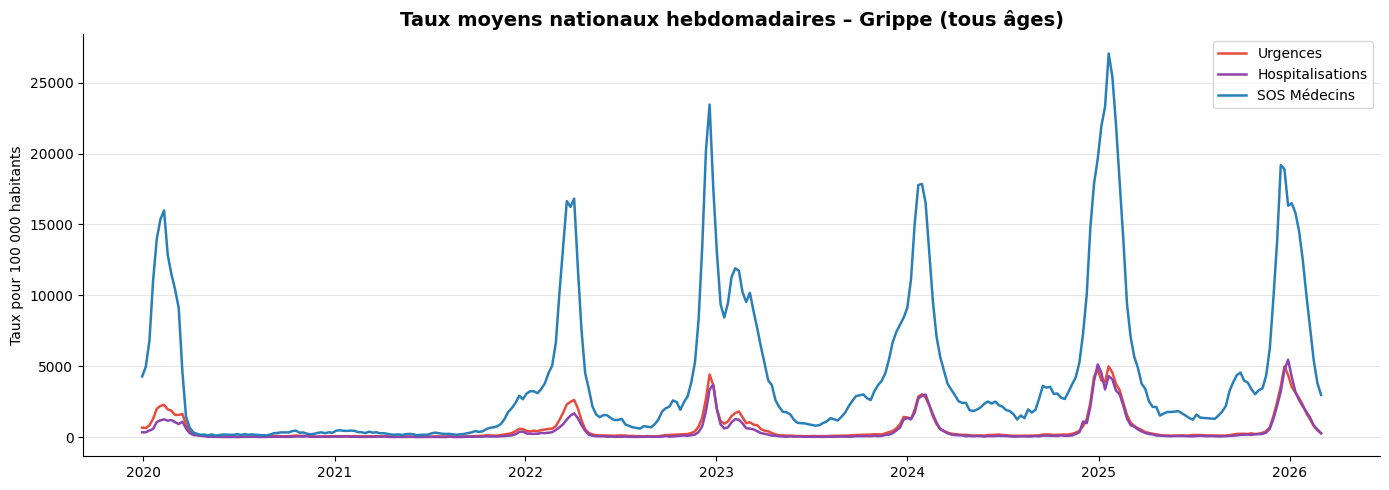

In [27]:
national = (
    tous.groupby('date')[['tx_urgences', 'tx_hospit', 'tx_sos']]
        .mean()
        .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(national['date'], national['tx_urgences'], label='Urgences',  color='#e74c3c', linewidth=1.8)
ax.plot(national['date'], national['tx_hospit'],   label='Hospitalisations', color='#8e44ad', linewidth=1.8)
ax.plot(national['date'], national['tx_sos'],      label='SOS Médecins', color='#2980b9', linewidth=1.8)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Taux moyens nationaux hebdomadaires – Grippe (tous âges)', fontsize=14, fontweight='bold')
ax.set_ylabel('Taux pour 100 000 habitants')
ax.legend()
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## 2 – Area chart · Comparaison des classes d'âge (urgences)

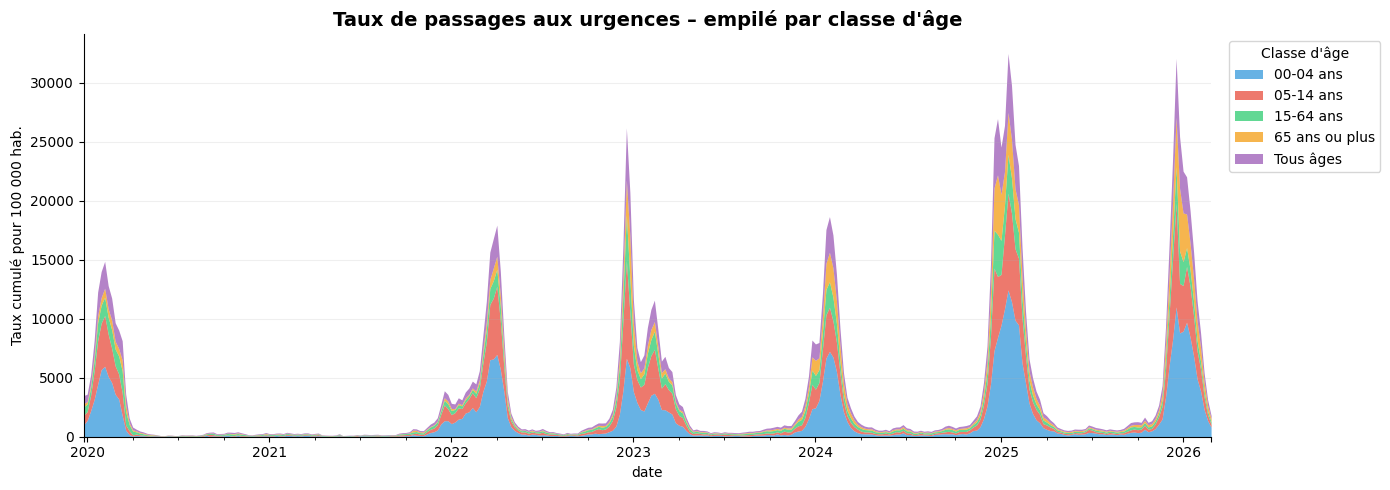

In [ ]:
age_ts = (
    df.groupby(['date', 'age'])['tx_urgences']
      .mean()
      .unstack('age')
      .fillna(0)
)

palette = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
fig, ax = plt.subplots(figsize=(14, 5))
age_ts.plot.area(ax=ax, color=palette, alpha=0.75, linewidth=0)


ax.set_title('Taux de passages aux urgences – empilé par classe d\'âge', fontsize=14, fontweight='bold')
ax.set_ylabel('Taux cumulé pour 100 000 hab.')
ax.legend(title="Classe d'âge", bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

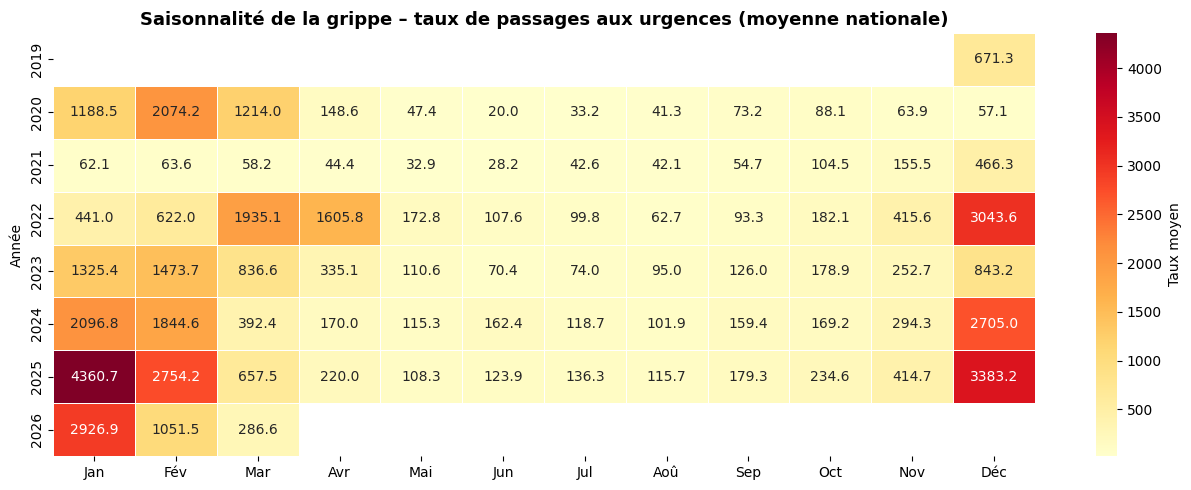

In [29]:
hm_data = (
    tous.groupby(['annee', 'mois'])['tx_urgences']
        .mean()
        .unstack('mois')
)
hm_data.columns = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    hm_data, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Taux moyen'}
)
ax.set_title('Saisonnalité de la grippe – taux de passages aux urgences (moyenne nationale)', fontsize=13, fontweight='bold')
ax.set_ylabel('Année')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

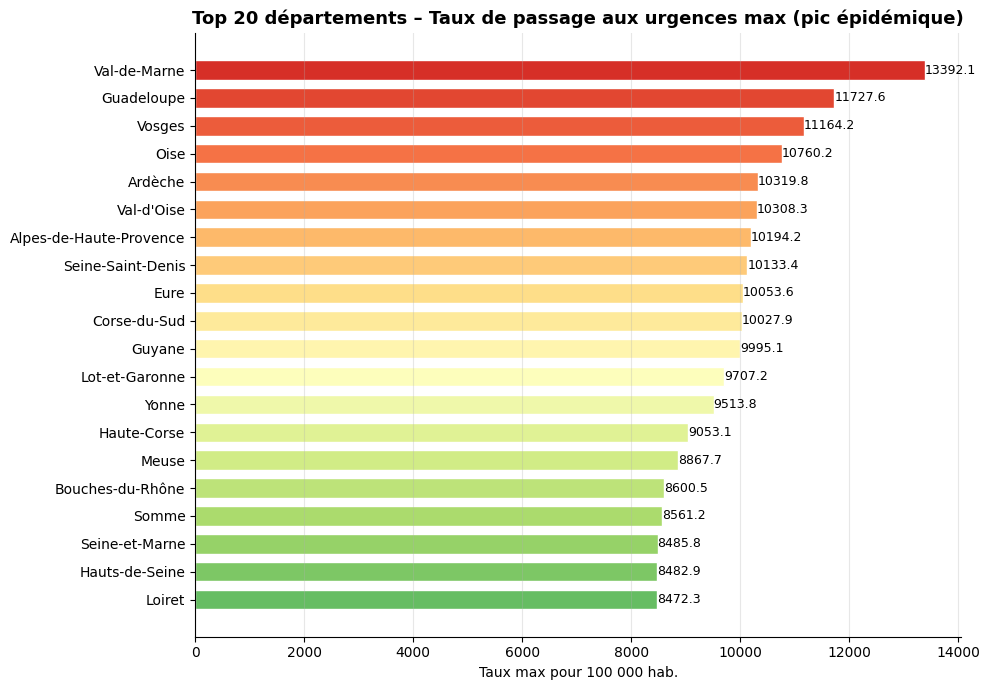

In [30]:
top_deps = (
    tous.groupby('departement')['tx_urgences']
        .max()
        .nlargest(20)
        .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(top_deps)))
bars = ax.barh(top_deps.index, top_deps.values, color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, top_deps.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', ha='left', fontsize=9)

ax.set_title('Top 20 départements – Taux de passage aux urgences max (pic épidémique)', fontsize=13, fontweight='bold')
ax.set_xlabel('Taux max pour 100 000 hab.')
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

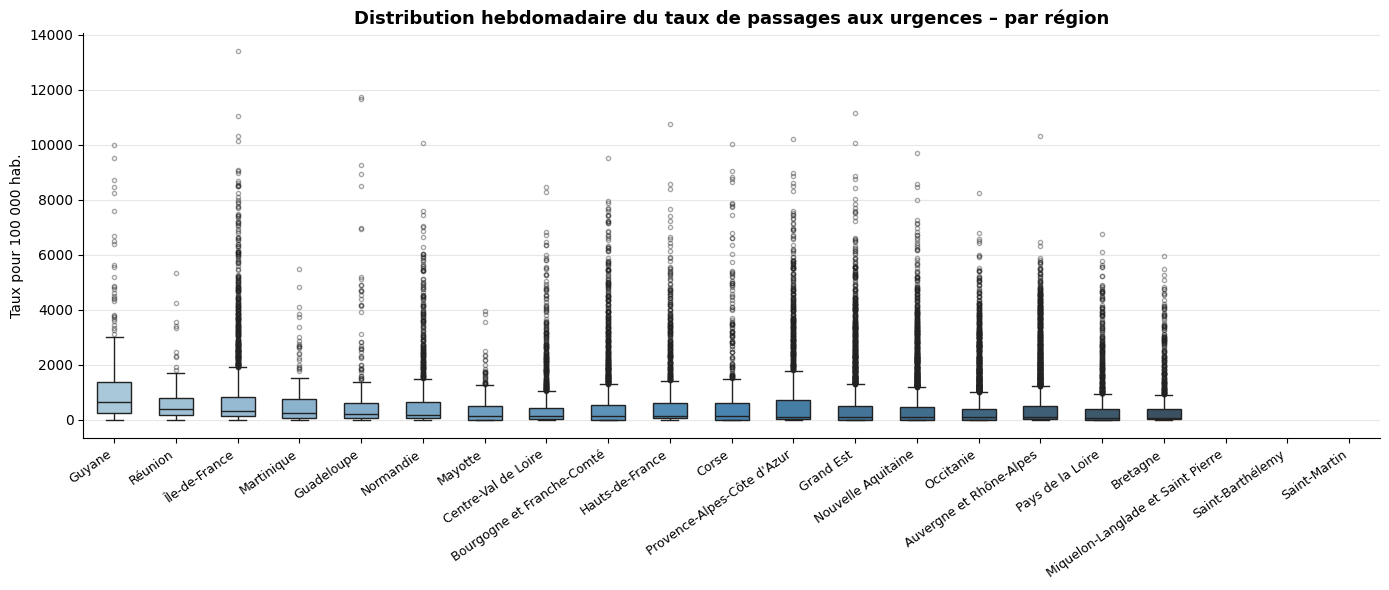

In [31]:
region_order = (
    tous.groupby('region')['tx_urgences']
        .median()
        .sort_values(ascending=False)
        .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=tous[tous['tx_urgences'].notna()],
    x='region', y='tx_urgences',
    order=region_order,
    palette='Blues_d', width=0.55,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_title('Distribution hebdomadaire du taux de passages aux urgences – par région', fontsize=13, fontweight='bold')
ax.set_ylabel('Taux pour 100 000 hab.')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

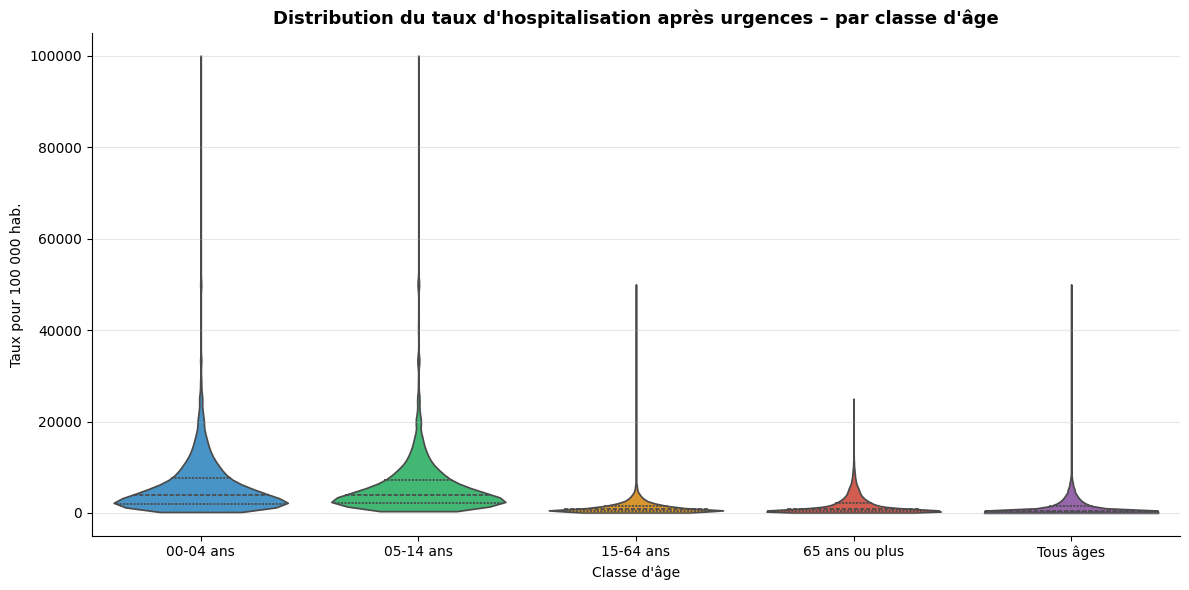

In [32]:
sub = df[df['tx_hospit'].notna() & (df['tx_hospit'] > 0)]

age_order = ['00-04 ans','05-14 ans','15-64 ans','65 ans ou plus','Tous âges']
palette_age = {'00-04 ans':'#3498db','05-14 ans':'#2ecc71','15-64 ans':'#f39c12',
               '65 ans ou plus':'#e74c3c','Tous âges':'#9b59b6'}

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=sub, x='age', y='tx_hospit',
    order=age_order, palette=palette_age,
    inner='quartile', cut=0, ax=ax
)
ax.set_title('Distribution du taux d\'hospitalisation après urgences – par classe d\'âge', fontsize=13, fontweight='bold')
ax.set_ylabel('Taux pour 100 000 hab.')
ax.set_xlabel("Classe d'âge")
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

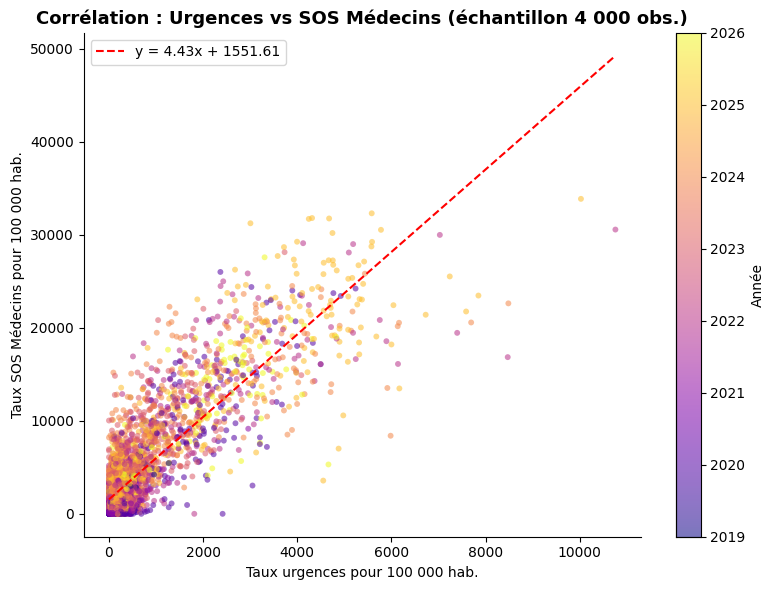

In [33]:
sc = tous[tous['tx_urgences'].notna() & tous['tx_sos'].notna()].sample(4000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    sc['tx_urgences'], sc['tx_sos'],
    c=sc['annee'], cmap='plasma', alpha=0.55, s=18, edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Année')

# regression line
m, b = np.polyfit(sc['tx_urgences'], sc['tx_sos'], 1)
x_line = np.linspace(sc['tx_urgences'].min(), sc['tx_urgences'].max(), 100)
ax.plot(x_line, m*x_line + b, color='red', linewidth=1.5, linestyle='--', label=f'y = {m:.2f}x + {b:.2f}')

ax.set_xlabel('Taux urgences pour 100 000 hab.')
ax.set_ylabel('Taux SOS Médecins pour 100 000 hab.')
ax.set_title('Corrélation : Urgences vs SOS Médecins (échantillon 4 000 obs.)', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

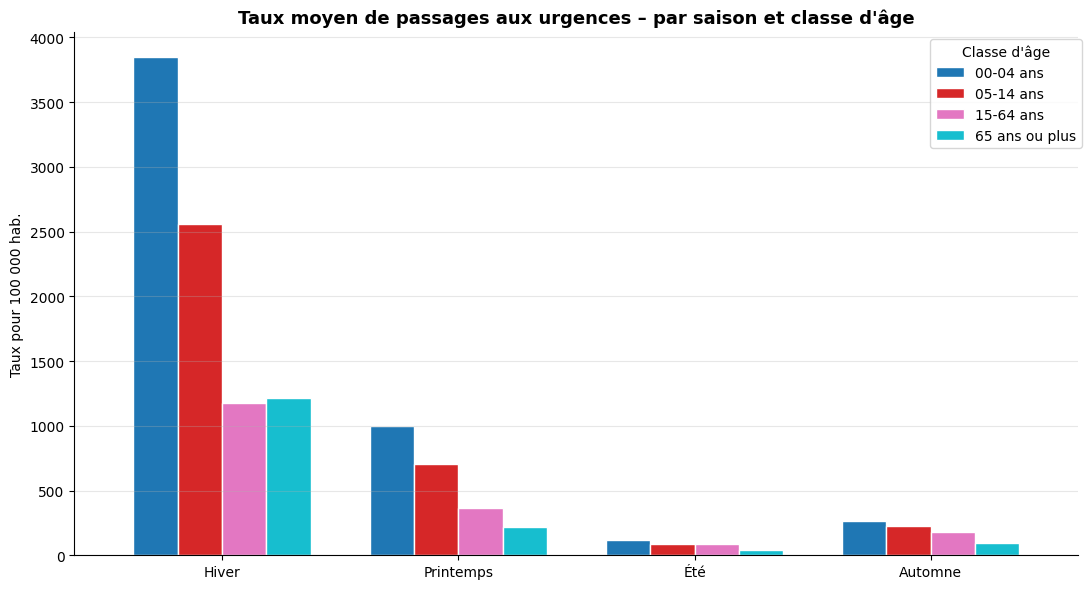

In [34]:
def saison(m):
    if m in [12, 1, 2]:  return 'Hiver'
    elif m in [3, 4, 5]: return 'Printemps'
    elif m in [6, 7, 8]: return 'Été'
    else:                return 'Automne'

df['saison'] = df['mois'].map(saison)
season_order = ['Hiver','Printemps','Été','Automne']
age_order2   = ['00-04 ans','05-14 ans','15-64 ans','65 ans ou plus']

grp = (
    df[df['age'].isin(age_order2)]
      .groupby(['saison','age'])['tx_urgences']
      .mean()
      .unstack('age')
      .reindex(season_order)
)

fig, ax = plt.subplots(figsize=(11, 6))
grp.plot.bar(ax=ax, width=0.75, colormap='tab10', edgecolor='white')
ax.set_title('Taux moyen de passages aux urgences – par saison et classe d\'âge', fontsize=13, fontweight='bold')
ax.set_ylabel('Taux pour 100 000 hab.')
ax.set_xlabel('')
ax.set_xticklabels(season_order, rotation=0)
ax.legend(title="Classe d'âge", bbox_to_anchor=(1.01, 1))
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [35]:
import json, urllib.request

# Download France departement GeoJSON (only once)
GEOJSON_URL = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
geojson_path = "/tmp/departements.geojson"
try:
    urllib.request.urlretrieve(GEOJSON_URL, geojson_path)
    with open(geojson_path) as f:
        geojson = json.load(f)
    has_geo = True
except Exception as e:
    print(f"GeoJSON non disponible ({e}) – cellule ignorée.")
    has_geo = False

if has_geo:
    dep_avg = (
        tous.groupby('dep_code_str')['tx_urgences']
            .mean()
            .reset_index()
            .rename(columns={'dep_code_str': 'code', 'tx_urgences': 'taux_moy'})
    )

    fig = px.choropleth(
        dep_avg,
        geojson=geojson,
        locations='code',
        featureidkey='properties.code',
        color='taux_moy',
        color_continuous_scale='YlOrRd',
        range_color=(0, dep_avg['taux_moy'].quantile(0.95)),
        labels={'taux_moy': 'Taux moyen'},
        title='Taux moyen de passages aux urgences – Grippe par département (2019-2026)'
    )
    fig.update_geos(fitbounds='locations', visible=False)
    fig.update_layout(margin=dict(l=0, r=0, t=40, b=0), width=800, height=550)
    fig.show()

In [36]:
reg_ts = (
    tous.groupby(['date', 'region'])['tx_urgences']
        .mean()
        .reset_index()
        .sort_values('date')
)
reg_ts['date_str'] = reg_ts['date'].dt.strftime('%Y-%m-%d')

fig = px.line(
    reg_ts,
    x='date_str', y='tx_urgences',
    color='region',
    title='Taux de passages aux urgences par région (tous âges) – 2019-2026',
    labels={'tx_urgences': 'Taux pour 100 000 hab.', 'date_str': 'Semaine', 'region': 'Région'}
)
fig.update_xaxes(tickangle=45, nticks=20)
fig.update_layout(height=500, legend=dict(font=dict(size=10)))
fig.show()

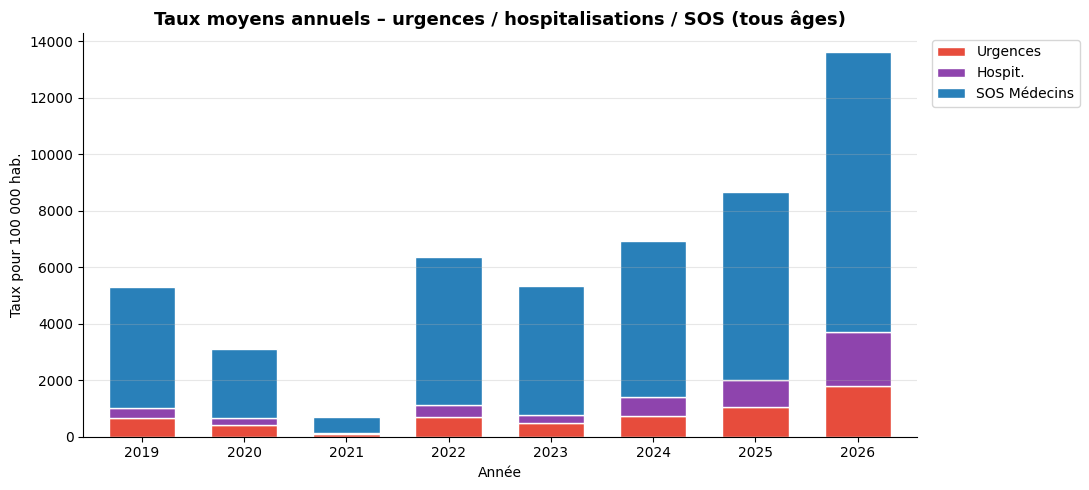

In [37]:
yr = (
    tous.groupby('annee')[['tx_urgences','tx_hospit','tx_sos']]
        .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))
yr.plot.bar(
    ax=ax, stacked=True,
    color=['#e74c3c','#8e44ad','#2980b9'],
    width=0.65, edgecolor='white'
)
ax.set_title('Taux moyens annuels – urgences / hospitalisations / SOS (tous âges)', fontsize=13, fontweight='bold')
ax.set_ylabel('Taux pour 100 000 hab.')
ax.set_xlabel('Année')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Urgences','Hospit.','SOS Médecins'], bbox_to_anchor=(1.01, 1))
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [38]:
bubble = (
    tous.groupby('region')[['tx_urgences','tx_hospit','tx_sos']]
        .mean()
        .reset_index()
        .dropna()
)

fig = px.scatter(
    bubble,
    x='tx_urgences', y='tx_sos',
    size='tx_hospit', color='region',
    hover_name='region',
    size_max=40,
    labels={
        'tx_urgences': 'Taux urgences (moy.)',
        'tx_sos':      'Taux SOS Médecins (moy.)',
        'tx_hospit':   'Taux hospit. (moy.)'
    },
    title='Relation Urgences / SOS Médecins par région – taille = taux hospit.'
)
fig.update_layout(height=520, showlegend=True)
fig.show()

In [39]:
nat_dash = tous.groupby('date')[['tx_urgences','tx_hospit','tx_sos']].mean().reset_index()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Urgences', 'Hospitalisations',
        'SOS Médecins', 'Comparaison normalisée'
    ],
    shared_xaxes=False
)

for col_name, row, col, color in [
    ('tx_urgences', 1, 1, '#e74c3c'),
    ('tx_hospit',   1, 2, '#8e44ad'),
    ('tx_sos',      2, 1, '#2980b9'),
]:
    fig.add_trace(
        go.Scatter(x=nat_dash['date'], y=nat_dash[col_name],
                   mode='lines', line=dict(color=color, width=1.5), showlegend=False),
        row=row, col=col
    )

# Panel 4: normalised overlay
for col_name, color, label in [
    ('tx_urgences','#e74c3c','Urgences'),
    ('tx_hospit','#8e44ad','Hospit.'),
    ('tx_sos','#2980b9','SOS'),
]:
    norm_col = (nat_dash[col_name] - nat_dash[col_name].min()) / \
               (nat_dash[col_name].max() - nat_dash[col_name].min())
    fig.add_trace(
        go.Scatter(x=nat_dash['date'], y=norm_col,
                   mode='lines', line=dict(color=color, width=1.5), name=label),
        row=2, col=2
    )

fig.update_layout(
    height=600, title_text='Dashboard – Indicateurs Grippe nationaux (tous âges)',
    legend=dict(orientation='h', y=-0.08)
)
fig.show()

## Model

In [51]:
tous.age.unique()

array(['Tous âges'], dtype=object)

In [55]:
tous.head()

,date,semaine,dep_code,departement,age,tx_urgences,tx_hospit,tx_sos,region,region_code,annee,mois,dep_code_str
1,2021-05-03,2021-S18,31,Haute-Garonne,Tous âges,0.000000,0.000000,0.000000,Occitanie,76,2021,5,31
8,2021-05-31,2021-S22,31,Haute-Garonne,Tous âges,0.000000,0.000000,0.000000,Occitanie,76,2021,5,31
17,2021-07-12,2021-S28,31,Haute-Garonne,Tous âges,16.463615,73.746313,0.000000,Occitanie,76,2021,7,31
24,2021-08-23,2021-S34,31,Haute-Garonne,Tous âges,17.911517,0.000000,0.000000,Occitanie,76,2021,8,31
28,2021-09-06,2021-S36,31,Haute-Garonne,Tous âges,31.215858,0.000000,189.933523,Occitanie,76,2021,9,31


In [58]:
FILE = "data/raw/Passage des patients/grippe-passages-aux-urgences-et-actes-sos-medecins-france.csv"

raw = pd.read_csv(FILE, low_memory=False)
raw.columns = ['date', 'semaine', 'age', 'tx_urgences', 'tx_hospit', 'tx_sos']
raw['date'] = pd.to_datetime(raw['date'])

In [59]:
raw.head()

,date,semaine,age,tx_urgences,tx_hospit,tx_sos
0,2019-12-30,2020-S01,00-04 ans,1748.614958,1162.147205,2508.277315
1,2019-12-30,2020-S01,15-64 ans,889.245533,285.038511,5724.738768
2,2020-01-06,2020-S02,Tous âges,856.894619,425.157358,5368.551540
3,2020-01-13,2020-S03,00-04 ans,3430.590986,2672.170324,6191.286804
4,2020-01-13,2020-S03,15-64 ans,826.526643,419.140761,7826.576577


In [62]:
ts = (
    raw[raw['age'] == 'Tous âges']
    .sort_values('date')
    .set_index('date')
    [['tx_urgences', 'tx_hospit', 'tx_sos']]
    .asfreq('W-MON')            # fréquence hebdomadaire explicite
)

# Série cible principale
y = ts['tx_urgences'].copy()

# Vérifications
print(f"Observations  : {len(y)}")
print(f"Timeline       : {y.index[0].date()} → {y.index[-1].date()}")
print(f"NaN Values  : {y.isna().sum()}")
print(f"Frequency     : {ts.index.freq}")
print(f"Min and Max     : {y.min():.1f} and {y.max():.1f}")
print(f"Mean       : {y.mean():.1f}  |  Std : {y.std():.1f}")
ts.head()

Observations  : 323
Timeline       : 2019-12-30 → 2026-03-02
NaN Values  : 0
Frequency     : <Week: weekday=0>
Min and Max     : 19.6 and 5554.5
Mean       : 669.3  |  Std : 1087.0


,tx_urgences,tx_hospit,tx_sos
date,,,
2019-12-30,900.949821,400.709302,4468.384648
2020-01-06,856.894619,425.157358,5368.551540
2020-01-13,1143.361987,569.734510,7228.582756
2020-01-20,1812.087766,796.268532,11163.737821
2020-01-27,2685.050146,1350.664678,15200.514735


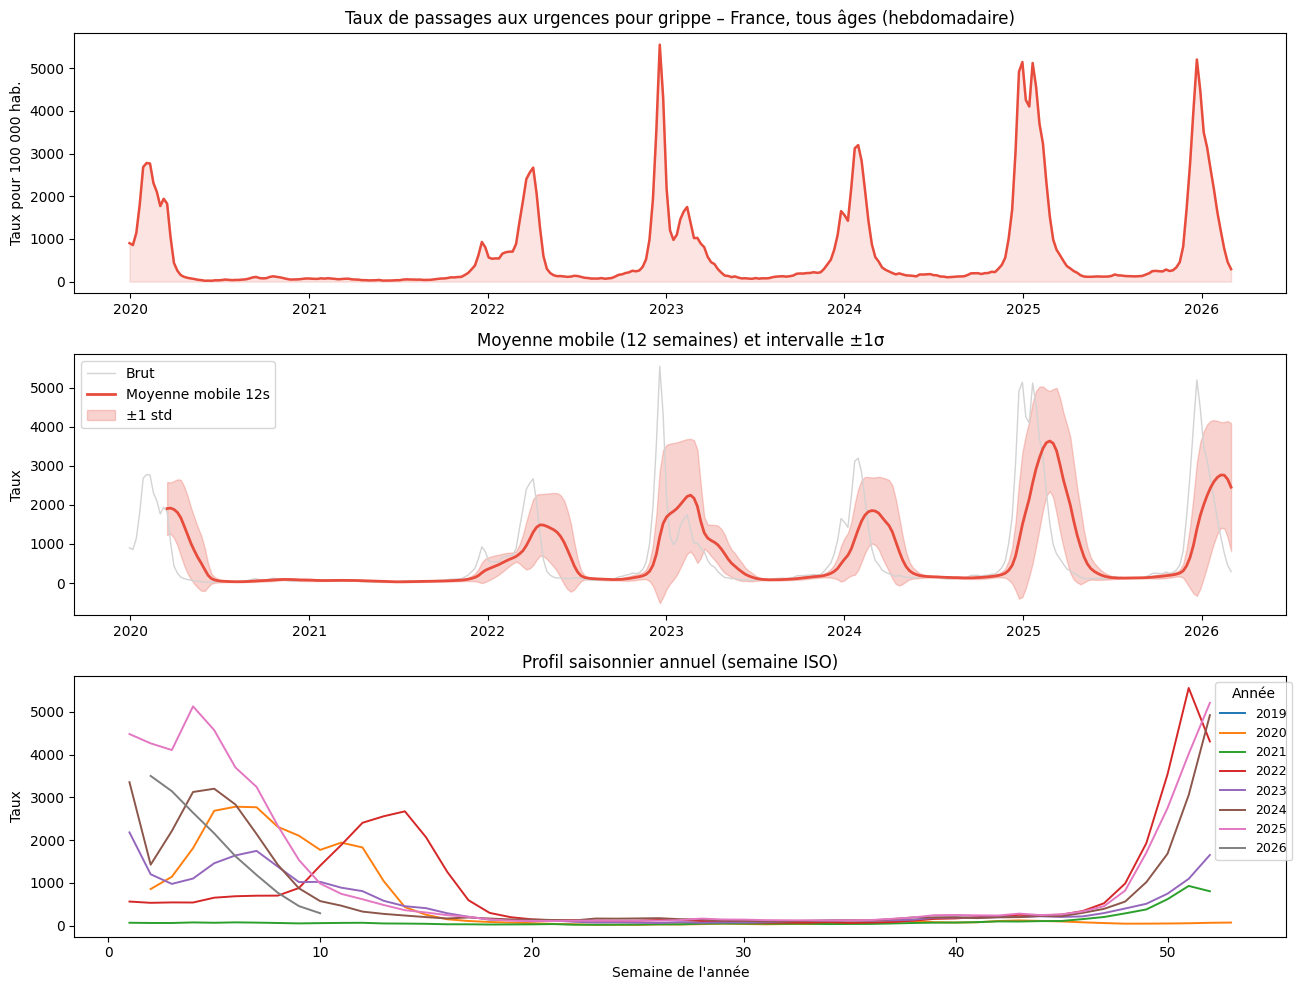

In [63]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# Série brute
axes[0].plot(y.index, y.values, color='#e74c3c', linewidth=1.8)
axes[0].set_title('Taux de passages aux urgences pour grippe – France, tous âges (hebdomadaire)')
axes[0].set_ylabel('Taux pour 100 000 hab.')
axes[0].fill_between(y.index, y.values, alpha=0.15, color='#e74c3c')

# Rolling mean & std (fenêtre 12 semaines)
roll_mean = y.rolling(12).mean()
roll_std  = y.rolling(12).std()
axes[1].plot(y.index, y.values, color='lightgray', linewidth=1, label='Brut')
axes[1].plot(roll_mean.index, roll_mean.values, color='#e74c3c', linewidth=2, label='Moyenne mobile 12s')
axes[1].fill_between(
    roll_mean.index,
    roll_mean - roll_std,
    roll_mean + roll_std,
    alpha=0.25, color='#e74c3c', label='±1 std'
)
axes[1].set_title('Moyenne mobile (12 semaines) et intervalle ±1σ')
axes[1].set_ylabel('Taux')
axes[1].legend()

# Distribution annuelle
y_df = y.reset_index()
y_df['annee'] = y_df['date'].dt.year
y_df['semaine_num'] = y_df['date'].dt.isocalendar().week.astype(int)
pivot = y_df.pivot_table(index='semaine_num', columns='annee', values='tx_urgences')
for col in pivot.columns:
    axes[2].plot(pivot.index, pivot[col], label=str(col), linewidth=1.4)
axes[2].set_title('Profil saisonnier annuel (semaine ISO)')
axes[2].set_xlabel('Semaine de l\'année')
axes[2].set_ylabel('Taux')
axes[2].legend(title='Année', bbox_to_anchor=(1.01, 1), fontsize=9)

plt.tight_layout()
plt.show()

## 3. Decomposition STL

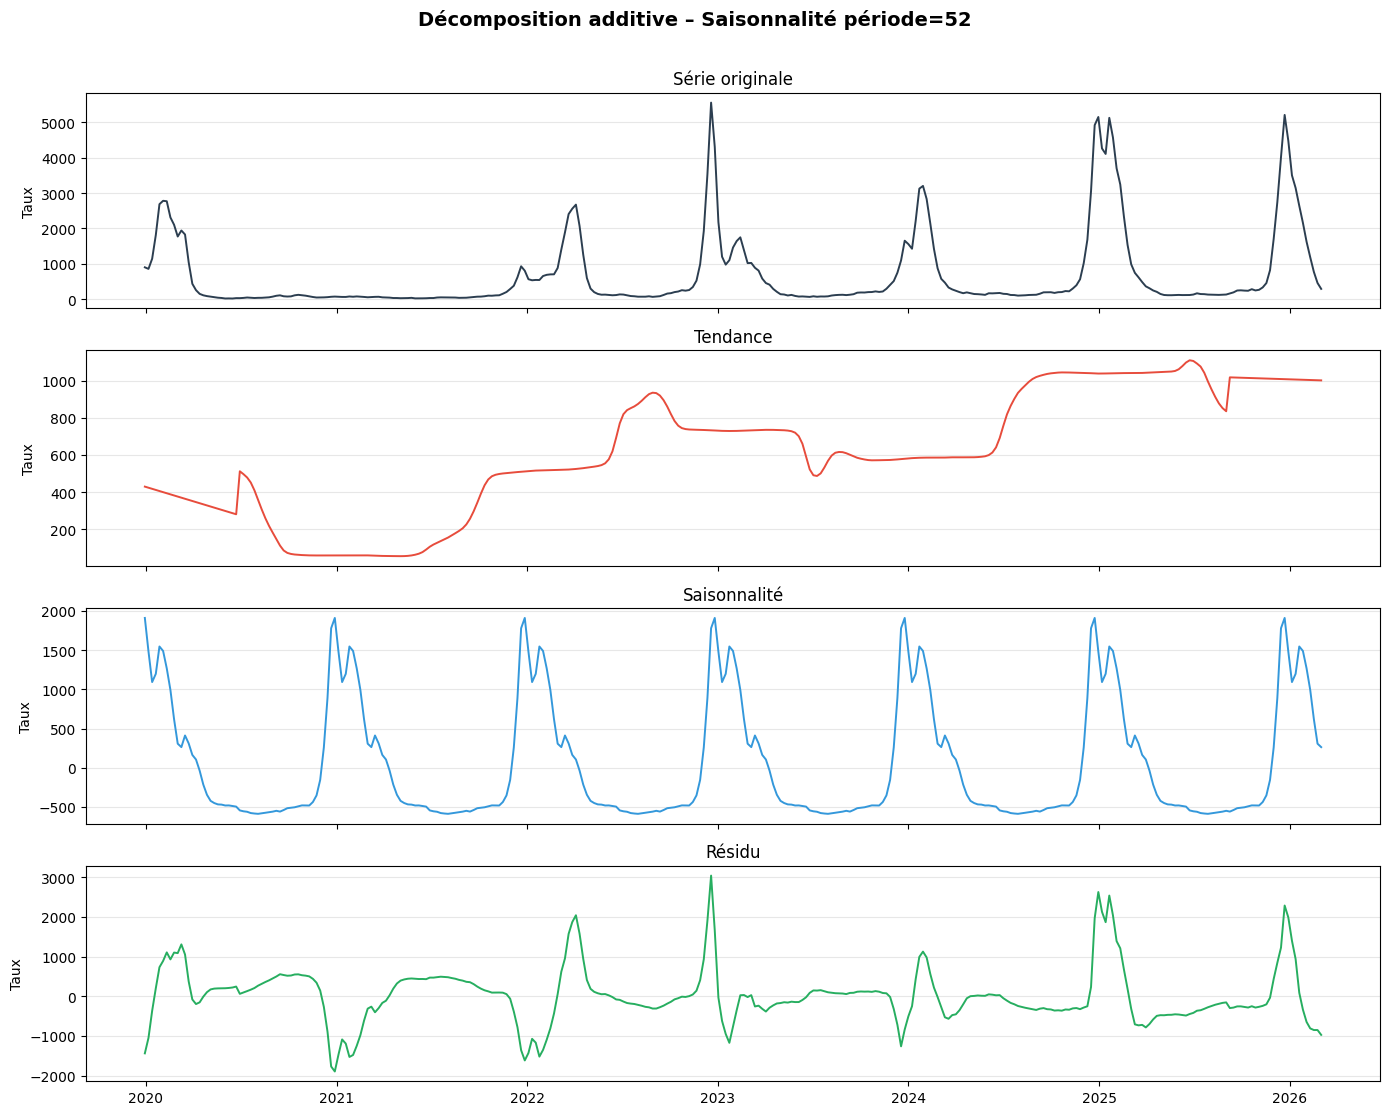

Variance totale      : 1177810.4
Variance tendance    : 105857.0  (9.0%)
Variance saisonnalité: 581756.1  (49.4%)
Variance résidu      : 502602.4  (42.7%)


In [66]:
# period = 52 semaines (saisonnalité annuelle)
decomp = seasonal_decompose(y, model='additive', period=52, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
components = [
    (y,                  'Série originale',  '#2c3e50'),
    (decomp.trend,       'Tendance',         '#e74c3c'),
    (decomp.seasonal,    'Saisonnalité',     '#3498db'),
    (decomp.resid,       'Résidu',           '#27ae60'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.4)
    ax.set_title(title)
    ax.set_ylabel('Taux')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Décomposition additive – Saisonnalité période=52', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Variance expliquée
var_total = np.var(y.dropna())
print(f"Variance totale      : {var_total:.1f}")
print(f"Variance tendance    : {np.var(decomp.trend.dropna()):.1f}  ({100*np.var(decomp.trend.dropna())/var_total:.1f}%)")
print(f"Variance saisonnalité: {np.var(decomp.seasonal.dropna()):.1f}  ({100*np.var(decomp.seasonal.dropna())/var_total:.1f}%)")
print(f"Variance résidu      : {np.var(decomp.resid.dropna()):.1f}  ({100*np.var(decomp.resid.dropna())/var_total:.1f}%)")

In [67]:
def run_adf(series, label='Série'):
    """Augmented Dickey-Fuller – H0 : non-stationnaire"""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{'─'*55}")
    print(f"ADF – {label}")
    print(f"  Statistique      : {result[0]:.4f}")
    print(f"  p-value          : {result[1]:.4f}")
    print(f"  Lags utilisés    : {result[2]}")
    print(f"  Obs. utilisées   : {result[3]}")
    for k, v in result[4].items():
        print(f"  Valeur critique {k}: {v:.4f}")
    conclusion = "Stationnaire ✓" if result[1] < 0.05 else "Non-stationnaire ✗"
    print(f"  → {conclusion} (α=5%)")
    return result[1]

def run_kpss(series, label='Série', regression='c'):
    """KPSS – H0 : stationnaire"""
    result = kpss(series.dropna(), regression=regression, nlags='auto')
    print(f"\n{'─'*55}")
    print(f"KPSS – {label}")
    print(f"  Statistique      : {result[0]:.4f}")
    print(f"  p-value          : {result[1]:.4f}")
    for k, v in result[3].items():
        print(f"  Valeur critique {k}: {v:.4f}")
    conclusion = "Stationnaire ✓" if result[1] > 0.05 else "Non-stationnaire ✗"
    print(f"  → {conclusion} (α=5%)")
    return result[1]

# ── Série brute ──────────────────────────────────────────────────────────────
print("\n" + "═"*55)
print("SÉRIE ORIGINALE")
adf_p0   = run_adf(y,   'Brute')
kpss_p0  = run_kpss(y,  'Brute')

# ── Différenciation d=1 ──────────────────────────────────────────────────────
y_diff1 = y.diff(1).dropna()
print("\n" + "═"*55)
print("SÉRIE DIFFÉRENCIÉE (d=1)")
adf_p1  = run_adf(y_diff1,  'diff(1)')
kpss_p1 = run_kpss(y_diff1, 'diff(1)')

# ── Conclusion ───────────────────────────────────────────────────────────────
print("\n" + "═"*55)
print("CONCLUSION")
d_order = 0 if (adf_p0 < 0.05 and kpss_p0 > 0.05) else 1
print(f"  Ordre d recommandé : d = {d_order}")


═══════════════════════════════════════════════════════
SÉRIE ORIGINALE

───────────────────────────────────────────────────────
ADF – Brute
  Statistique      : -4.9819
  p-value          : 0.0000
  Lags utilisés    : 5
  Obs. utilisées   : 317
  Valeur critique 1%: -3.4511
  Valeur critique 5%: -2.8707
  Valeur critique 10%: -2.5717
  → Stationnaire ✓ (α=5%)

───────────────────────────────────────────────────────
KPSS – Brute
  Statistique      : 0.2915
  p-value          : 0.1000
  Valeur critique 10%: 0.3470
  Valeur critique 5%: 0.4630
  Valeur critique 2.5%: 0.5740
  Valeur critique 1%: 0.7390
  → Stationnaire ✓ (α=5%)

═══════════════════════════════════════════════════════
SÉRIE DIFFÉRENCIÉE (d=1)

───────────────────────────────────────────────────────
ADF – diff(1)
  Statistique      : -9.0285
  p-value          : 0.0000
  Lags utilisés    : 3
  Obs. utilisées   : 318
  Valeur critique 1%: -3.4511
  Valeur critique 5%: -2.8707
  Valeur critique 10%: -2.5716
  → Stationnaire

/tmp/ipykernel_9093/2535627728.py:18: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/tmp/ipykernel_9093/2535627728.py:18: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




## ACF and PCF

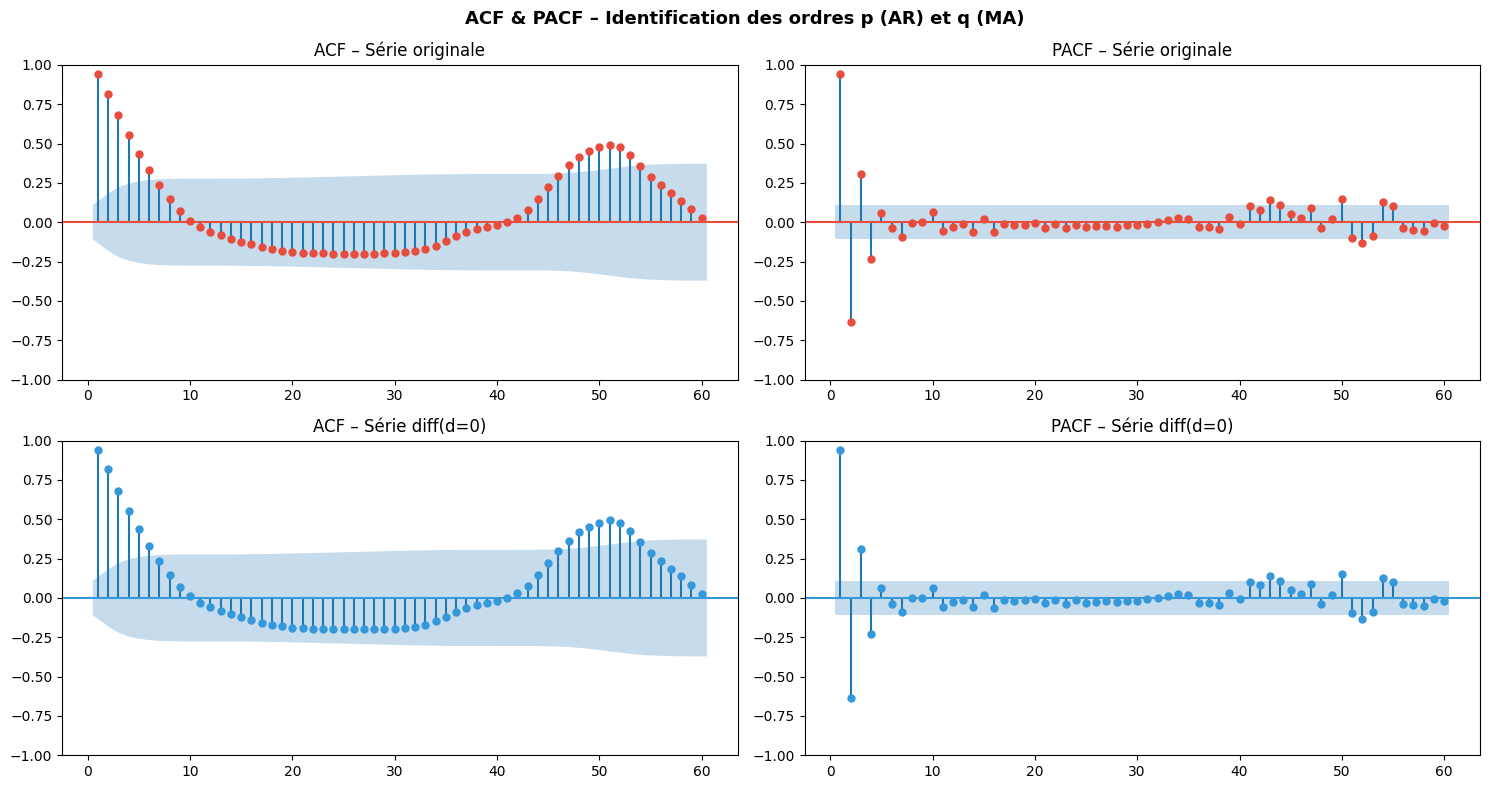

Bande IC 95% : ±0.1091
Lags PACF significatifs (→ AR ordre p) : [1, 2, 3, 4]
Lags ACF  significatifs (→ MA ordre q) : [1, 2, 3, 4, 5, 6, 7, 8, 15, 16]

Ordres retenus : p=1, d=0, q=1


In [68]:
NLAGS = 60

# Choisir la série à analyser selon d
y_stat = y_diff1 if d_order == 1 else y

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# ACF série brute
plot_acf(y, lags=NLAGS, ax=axes[0, 0], color='#e74c3c', zero=False)
axes[0, 0].set_title('ACF – Série originale')

# PACF série brute
plot_pacf(y, lags=NLAGS, ax=axes[0, 1], color='#e74c3c', zero=False, method='ywm')
axes[0, 1].set_title('PACF – Série originale')

# ACF différenciée
plot_acf(y_stat, lags=NLAGS, ax=axes[1, 0], color='#3498db', zero=False)
axes[1, 0].set_title(f'ACF – Série diff(d={d_order})')

# PACF différenciée
plot_pacf(y_stat, lags=NLAGS, ax=axes[1, 1], color='#3498db', zero=False, method='ywm')
axes[1, 1].set_title(f'PACF – Série diff(d={d_order})')

plt.suptitle('ACF & PACF – Identification des ordres p (AR) et q (MA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Lecture des seuils de signification ─────────────────────────────────────
acf_vals  = acf(y_stat,  nlags=NLAGS, fft=True)
pacf_vals = pacf(y_stat, nlags=NLAGS, method='ywm')
ci_band   = 1.96 / np.sqrt(len(y_stat))

p_candidates = [i for i in range(1, 21) if abs(pacf_vals[i]) > ci_band]
q_candidates = [i for i in range(1, 21) if abs(acf_vals[i])  > ci_band]

print(f"Bande IC 95% : ±{ci_band:.4f}")
print(f"Lags PACF significatifs (→ AR ordre p) : {p_candidates[:10]}")
print(f"Lags ACF  significatifs (→ MA ordre q) : {q_candidates[:10]}")
print()
p_best = p_candidates[0] if p_candidates else 1
q_best = q_candidates[0] if q_candidates else 1
print(f"Ordres retenus : p={p_best}, d={d_order}, q={q_best}")

## Split

Train : 259 obs. (2019-12-30 → 2024-12-09)
Test  : 64  obs. (2024-12-16  → 2026-03-02)


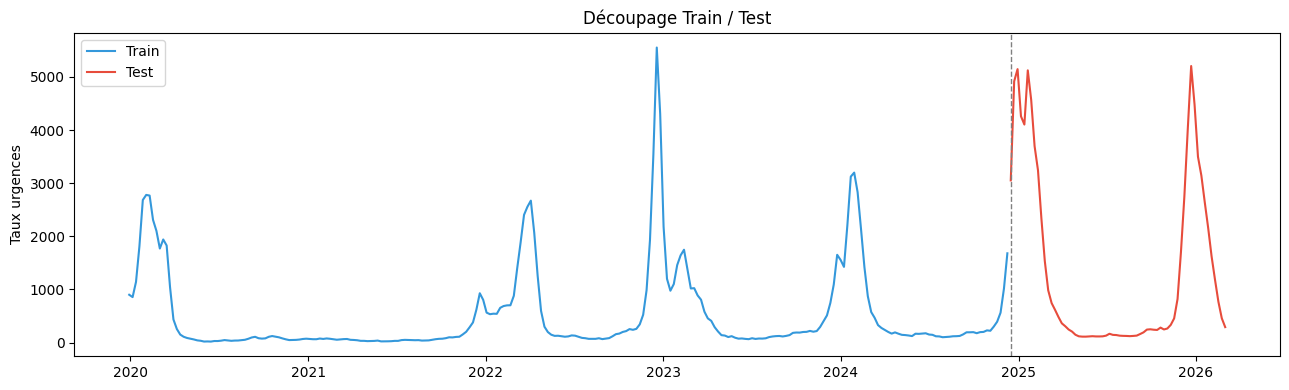

In [69]:
HORIZON = int(len(y) * 0.20)  # ~20% = environ 65 semaines
train = y.iloc[:-HORIZON]
test  = y.iloc[-HORIZON:]

print(f"Train : {len(train)} obs. ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test  : {len(test)}  obs. ({test.index[0].date()}  → {test.index[-1].date()})")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index, train.values, label='Train', color='#3498db', linewidth=1.5)
ax.plot(test.index,  test.values,  label='Test',  color='#e74c3c', linewidth=1.5)
ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=1)
ax.set_title('Découpage Train / Test')
ax.set_ylabel('Taux urgences')
ax.legend()
plt.tight_layout()
plt.show()

# Dictionnaire résultats
results = {}

In [70]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def compute_metrics(y_true, y_pred, label, aic=None, bic=None):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mape(y_true, y_pred)
    row = {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape_val}
    if aic is not None: row['AIC'] = aic
    if bic is not None: row['BIC'] = bic
    results[label] = row
    print(f"{label:<22}  MAE={mae:>8.1f}  RMSE={rmse:>8.1f}  MAPE={mape_val:>6.2f}%", end='')
    if aic: print(f"  AIC={aic:>10.1f}  BIC={bic:>10.1f}", end='')
    print()
    return row

def plot_forecast(train, test, pred, ci_lower=None, ci_upper=None, title='', color='#8e44ad'):
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(train.index, train.values, color='#3498db', linewidth=1.3, label='Train')
    ax.plot(test.index,  test.values,  color='#e74c3c', linewidth=1.8, label='Réel (test)')
    ax.plot(test.index,  pred,          color=color,    linewidth=1.8, linestyle='--', label='Prévision')
    if ci_lower is not None and ci_upper is not None:
        ax.fill_between(test.index, ci_lower, ci_upper, alpha=0.2, color=color, label='IC 95%')
    ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1)
    ax.set_title(title)
    ax.set_ylabel('Taux urgences')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

def diagnose_residuals(residuals, model_name):
    """Tests complets sur les résidus d'un modèle."""
    res = np.array(residuals)
    res = res[~np.isnan(res)]

    fig = plt.figure(figsize=(14, 8))
    gs  = gridspec.GridSpec(2, 3, figure=fig)

    # Résidus dans le temps
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(res, color='#2c3e50', linewidth=1)
    ax0.axhline(0, color='red', linestyle='--', linewidth=1)
    ax0.set_title(f'Résidus – {model_name}')
    ax0.set_ylabel('Résidu')

    # Histogramme + KDE
    ax1 = fig.add_subplot(gs[1, 0])
    sns.histplot(res, kde=True, bins=30, color='#3498db', ax=ax1)
    ax1.set_title('Distribution des résidus')

    # QQ-plot
    from scipy.stats import probplot
    ax2 = fig.add_subplot(gs[1, 1])
    probplot(res, plot=ax2)
    ax2.set_title('QQ-plot')

    # ACF résidus
    ax3 = fig.add_subplot(gs[1, 2])
    plot_acf(res, lags=40, ax=ax3, color='#e74c3c', zero=False)
    ax3.set_title('ACF des résidus')

    plt.suptitle(f'Diagnostic des résidus – {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Tests statistiques
    dw    = durbin_watson(res)
    lb    = acorr_ljungbox(res, lags=[10, 20], return_df=True)
    jb_s, jb_p, _, _ = jarque_bera(res)
    sw_s, sw_p = shapiro(res[:min(len(res), 5000)])

    print(f"\n{'─'*55}")
    print(f"Tests diagnostics – {model_name}")
    print(f"  Durbin-Watson       : {dw:.4f}  (2=pas d'autocorr.)")
    print(f"  Jarque-Bera         : stat={jb_s:.2f}, p={jb_p:.4f}",
          '→ Normalité ✓' if jb_p > 0.05 else '→ Non-normal ✗')
    print(f"  Shapiro-Wilk        : stat={sw_s:.4f}, p={sw_p:.4f}",
          '→ Normalité ✓' if sw_p > 0.05 else '→ Non-normal ✗')
    print("  Ljung-Box:")
    for _, row in lb.iterrows():
        lag = int(row.name)
        p   = row['lb_pvalue']
        print(f"    Lag {lag:2d}: p={p:.4f}",
              '→ Résidus non-corrélés ✓' if p > 0.05 else '→ Autocorrélation résiduelle ✗')

print("Helpers définis ✓")

Helpers définis ✓


## Models

### AR

MODÈLE AR

Ordre AR optimal par AIC : p = 15


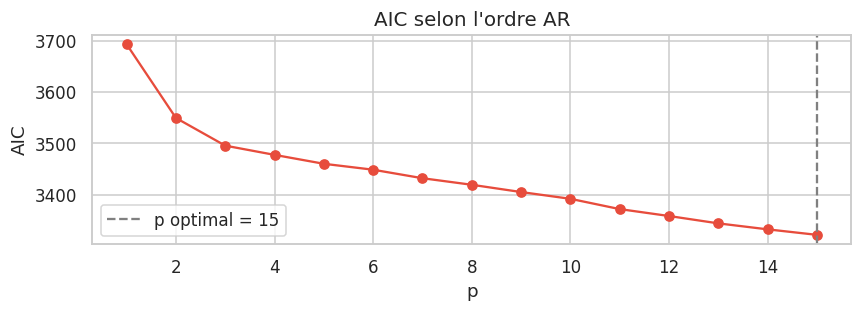

AR(p=15)                MAE=  1029.9  RMSE=  1648.8  MAPE=115.60%  AIC=    3322.0  BIC=    3381.4


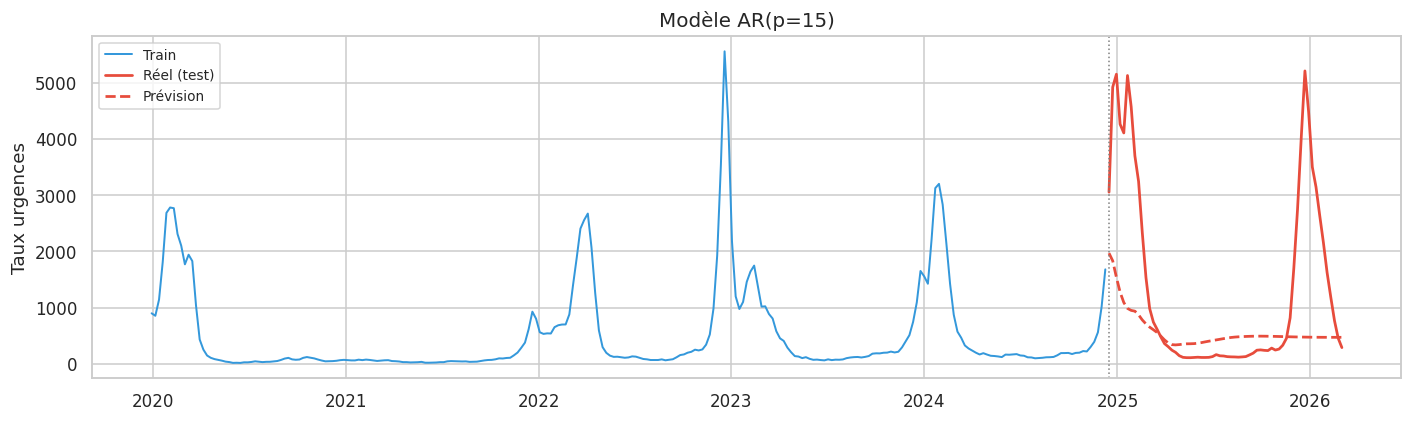

NameError: name 'gridspec' is not defined

<Figure size 1540x880 with 0 Axes>

In [75]:
print("=" * 60)
print("MODÈLE AR")
print("=" * 60)

# Sélection d'ordre par AIC
ar_aic = {}
for p_try in range(1, 16):
    try:
        m = AutoReg(train, lags=p_try, old_names=False).fit()
        ar_aic[p_try] = m.aic
    except:
        pass

p_ar = min(ar_aic, key=ar_aic.get)
print(f"\nOrdre AR optimal par AIC : p = {p_ar}")

# Graphique AIC vs p
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(list(ar_aic.keys()), list(ar_aic.values()), marker='o', color='#e74c3c')
ax.axvline(p_ar, color='gray', linestyle='--', label=f'p optimal = {p_ar}')
ax.set_title('AIC selon l\'ordre AR')
ax.set_xlabel('p')
ax.set_ylabel('AIC')
ax.legend()
plt.tight_layout()
plt.show()

# Ajustement sur train, prévision sur test
ar_model = AutoReg(train, lags=p_ar, old_names=False).fit()
ar_pred  = ar_model.predict(start=len(train), end=len(train) + len(test) - 1)
ar_pred.index = test.index

compute_metrics(test, ar_pred, f'AR(p={p_ar})',
                aic=ar_model.aic, bic=ar_model.bic)
plot_forecast(train, test, ar_pred, title=f'Modèle AR(p={p_ar})', color='#e74c3c')
diagnose_residuals(ar_model.resid, f'AR(p={p_ar})')
print(ar_model.summary())

MODÈLE MA

Ordre MA optimal par AIC : q = 9


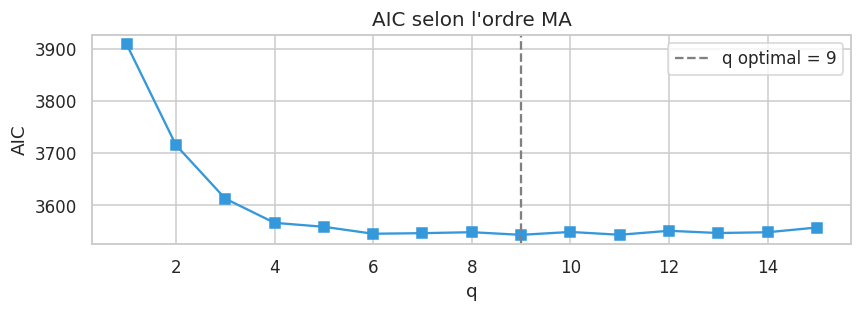

MA(q=9)                 MAE=  1088.0  RMSE=  1681.7  MAPE=141.28%  AIC=    3542.9  BIC=    3582.0


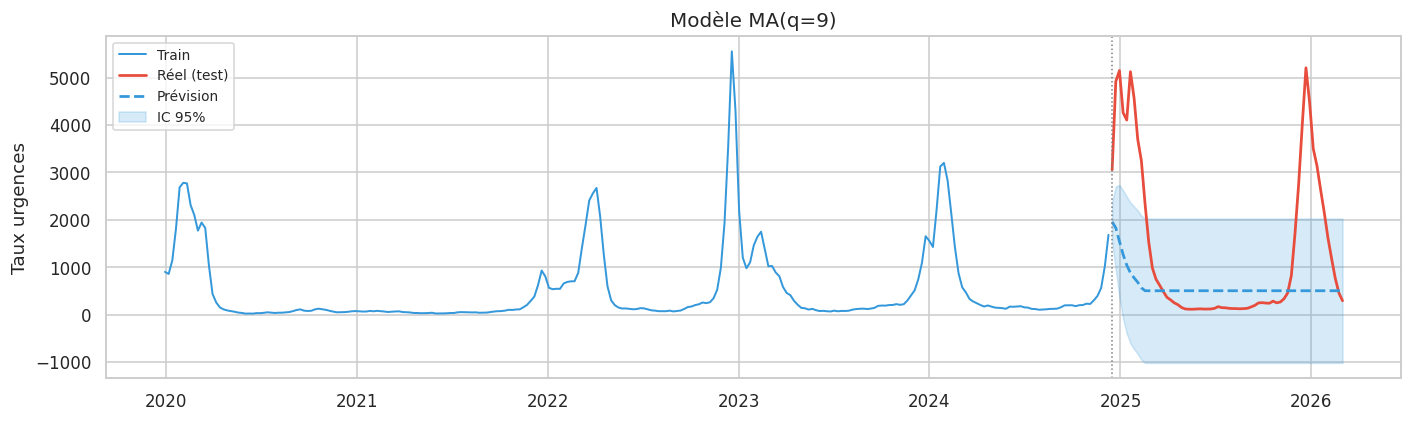

NameError: name 'gridspec' is not defined

<Figure size 1540x880 with 0 Axes>

In [76]:
print("=" * 60)
print("MODÈLE MA")
print("=" * 60)

# Sélection d'ordre par AIC
ma_aic = {}
for q_try in range(1, 16):
    try:
        m = ARIMA(train, order=(0, d_order, q_try)).fit()
        ma_aic[q_try] = m.aic
    except:
        pass

q_ma = min(ma_aic, key=ma_aic.get)
print(f"\nOrdre MA optimal par AIC : q = {q_ma}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(list(ma_aic.keys()), list(ma_aic.values()), marker='s', color='#3498db')
ax.axvline(q_ma, color='gray', linestyle='--', label=f'q optimal = {q_ma}')
ax.set_title('AIC selon l\'ordre MA')
ax.set_xlabel('q')
ax.set_ylabel('AIC')
ax.legend()
plt.tight_layout()
plt.show()

ma_model = ARIMA(train, order=(0, d_order, q_ma)).fit()

fc = ma_model.get_forecast(steps=len(test))
ma_pred = fc.predicted_mean
ma_pred.index = test.index
ma_ci = fc.conf_int(alpha=0.05)
ma_ci.index = test.index

compute_metrics(test, ma_pred, f'MA(q={q_ma})',
                aic=ma_model.aic, bic=ma_model.bic)
plot_forecast(train, test, ma_pred,
              ci_lower=ma_ci.iloc[:, 0], ci_upper=ma_ci.iloc[:, 1],
              title=f'Modèle MA(q={q_ma})', color='#3498db')
diagnose_residuals(ma_model.resid, f'MA(q={q_ma})')
print(ma_model.summary())

MODÈLE ARMA (grid search AIC)

Meilleur ARMA(5,2) par AIC = 3534.1


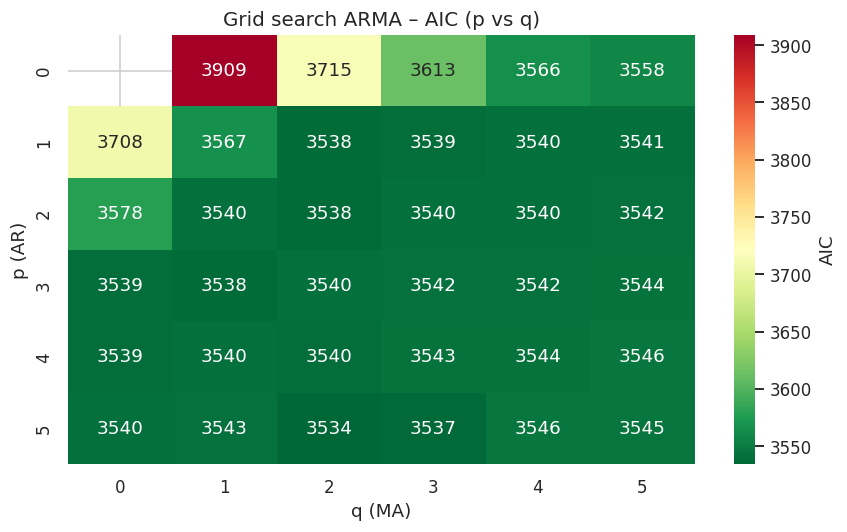

ARMA(5,2)               MAE=  1073.7  RMSE=  1655.0  MAPE=145.97%  AIC=    3534.1  BIC=    3566.1


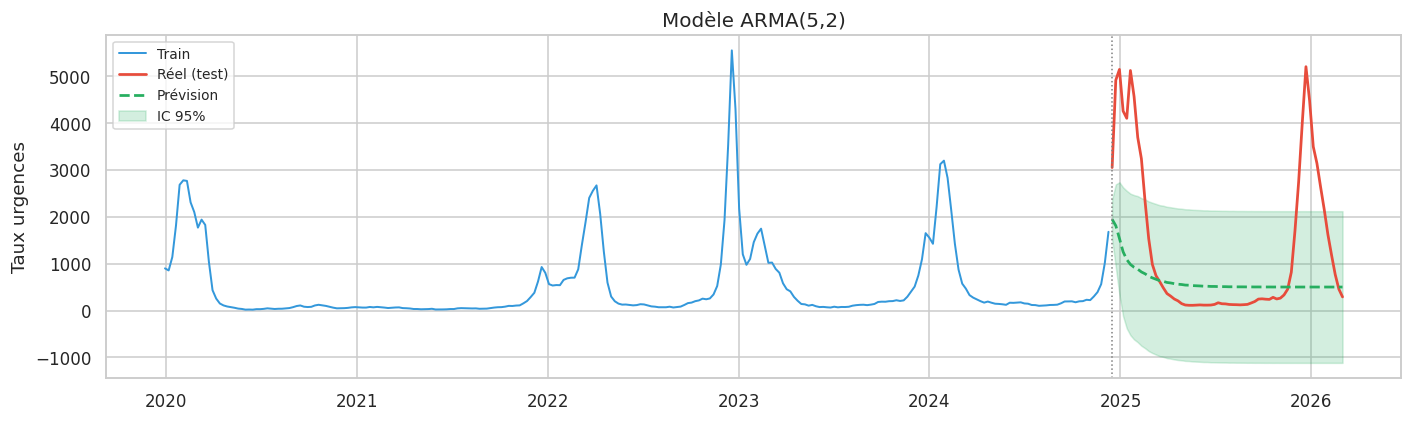

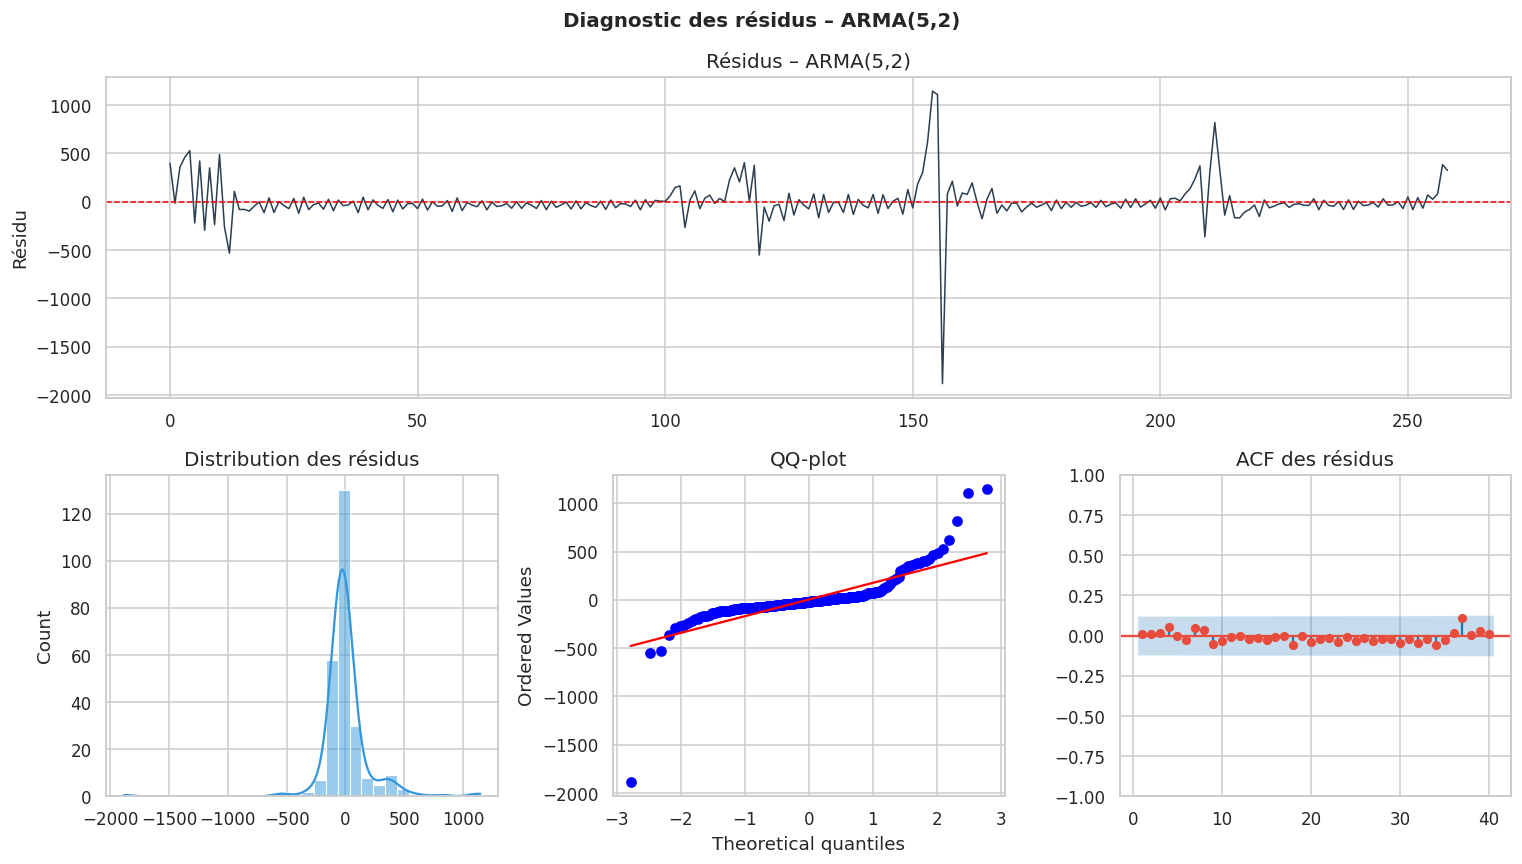


───────────────────────────────────────────────────────
Tests diagnostics – ARMA(5,2)
  Durbin-Watson       : 1.9562  (2=pas d'autocorr.)
  Jarque-Bera         : stat=8550.03, p=0.0000 → Non-normal ✗
  Shapiro-Wilk        : stat=0.6490, p=0.0000 → Non-normal ✗
  Ljung-Box:
    Lag 10: p=0.9784 → Résidus non-corrélés ✓
    Lag 20: p=0.9998 → Résidus non-corrélés ✓
                               SARIMAX Results                                
Dep. Variable:            tx_urgences   No. Observations:                  259
Model:                 ARIMA(5, 0, 2)   Log Likelihood               -1758.062
Date:                Sat, 14 Mar 2026   AIC                           3534.125
Time:                        16:46:22   BIC                           3566.136
Sample:                    12-30-2019   HQIC                          3546.995
                         - 12-09-2024                                         
Covariance Type:                  opg                                         
 

In [79]:
print("=" * 60)
print("MODÈLE ARMA (grid search AIC)")
print("=" * 60)

# Grid search p, q (d=0 pour ARMA pur)
arma_aic  = {}
for p_try in range(0, 6):
    for q_try in range(0, 6):
        if p_try == 0 and q_try == 0:
            continue
        try:
            m = ARIMA(train, order=(p_try, 0, q_try)).fit(method_kwargs={'warn_convergence': False})
            arma_aic[(p_try, q_try)] = m.aic
        except:
            pass

best_arma_order = min(arma_aic, key=arma_aic.get)
p_arma, q_arma  = best_arma_order
print(f"\nMeilleur ARMA({p_arma},{q_arma}) par AIC = {arma_aic[best_arma_order]:.1f}")

# Heatmap AIC
aic_df = pd.Series(arma_aic).unstack()
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(aic_df, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax,
            cbar_kws={'label': 'AIC'})
ax.set_xlabel('q (MA)')
ax.set_ylabel('p (AR)')
ax.set_title('Grid search ARMA – AIC (p vs q)')
plt.tight_layout()
plt.show()

arma_model = ARIMA(train, order=(p_arma, 0, q_arma)).fit()

fc = arma_model.get_forecast(steps=len(test))
arma_pred = fc.predicted_mean
arma_pred.index = test.index
arma_ci = fc.conf_int(alpha=0.05)
arma_ci.index = test.index

compute_metrics(test, arma_pred, f'ARMA({p_arma},{q_arma})',
                aic=arma_model.aic, bic=arma_model.bic)
plot_forecast(train, test, arma_pred,
              ci_lower=arma_ci.iloc[:, 0], ci_upper=arma_ci.iloc[:, 1],
              title=f'Modèle ARMA({p_arma},{q_arma})', color='#27ae60')
diagnose_residuals(arma_model.resid, f'ARMA({p_arma},{q_arma})')
print(arma_model.summary())

MODÈLE ARIMA (grid search p, d, q)

Meilleur ARIMA(2,2,4) par AIC = 3524.6

Top 10 ARIMA par AIC :
  (p,d,q)         AIC
  (2, 2, 4)       3524.6
  (1, 1, 3)       3525.4
  (3, 2, 4)       3525.9
  (3, 1, 2)       3526.1
  (2, 1, 3)       3526.5
  (4, 2, 4)       3526.5
  (4, 1, 1)       3526.5
  (1, 1, 4)       3526.6
  (3, 1, 3)       3527.8
  (2, 1, 4)       3528.5
ARIMA(2,2,4)            MAE=  1116.6  RMSE=  1571.1  MAPE=215.03%  AIC=    3524.6  BIC=    3549.4


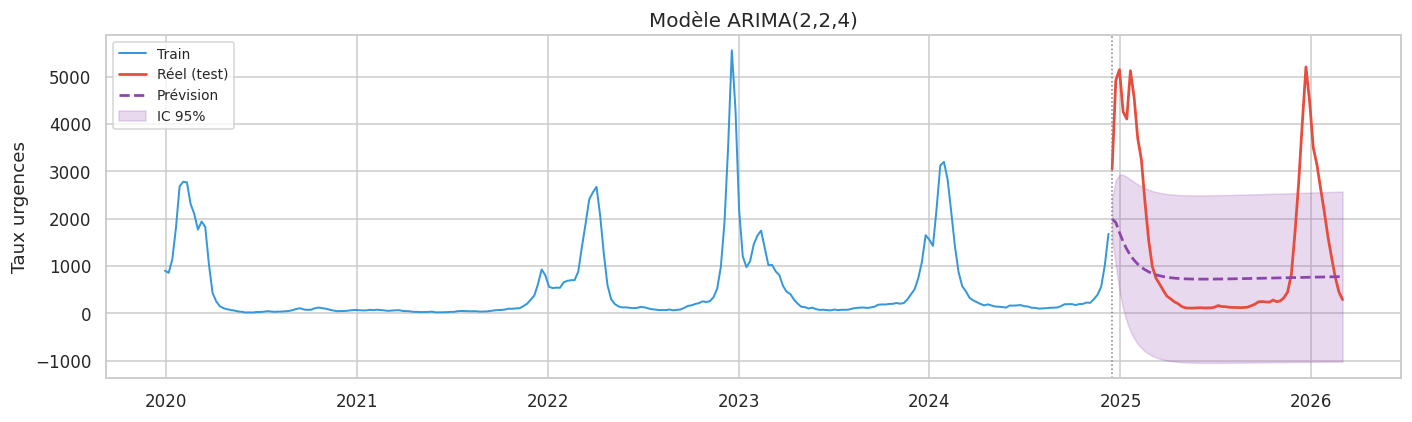

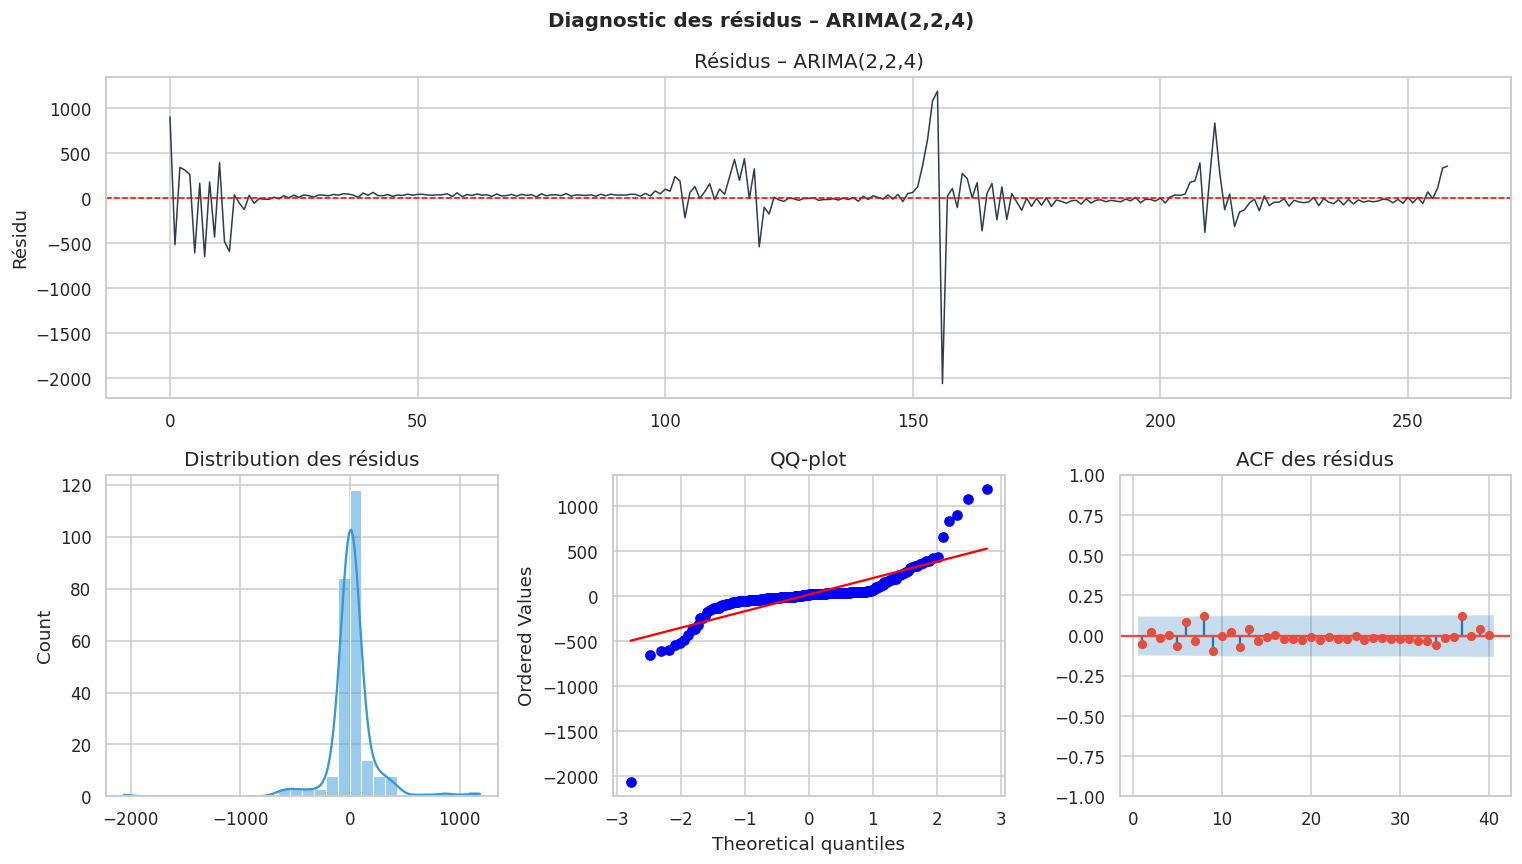


───────────────────────────────────────────────────────
Tests diagnostics – ARIMA(2,2,4)
  Durbin-Watson       : 2.0266  (2=pas d'autocorr.)
  Jarque-Bera         : stat=9130.77, p=0.0000 → Non-normal ✗
  Shapiro-Wilk        : stat=0.6291, p=0.0000 → Non-normal ✗
  Ljung-Box:
    Lag 10: p=0.3687 → Résidus non-corrélés ✓
    Lag 20: p=0.8419 → Résidus non-corrélés ✓
                               SARIMAX Results                                
Dep. Variable:            tx_urgences   No. Observations:                  259
Model:                 ARIMA(2, 2, 4)   Log Likelihood               -1755.300
Date:                Sat, 14 Mar 2026   AIC                           3524.600
Time:                        16:46:49   BIC                           3549.443
Sample:                    12-30-2019   HQIC                          3534.591
                         - 12-09-2024                                         
Covariance Type:                  opg                                        

In [80]:
print("=" * 60)
print("MODÈLE ARIMA (grid search p, d, q)")
print("=" * 60)

arima_aic = {}
for p_try in range(0, 5):
    for d_try in range(0, 3):
        for q_try in range(0, 5):
            if p_try == 0 and q_try == 0:
                continue
            try:
                m = ARIMA(train, order=(p_try, d_try, q_try)).fit()
                arima_aic[(p_try, d_try, q_try)] = m.aic
            except:
                pass

best_arima = min(arima_aic, key=arima_aic.get)
p_i, d_i, q_i = best_arima
print(f"\nMeilleur ARIMA({p_i},{d_i},{q_i}) par AIC = {arima_aic[best_arima]:.1f}")

# Top 10 configurations
top10 = sorted(arima_aic.items(), key=lambda x: x[1])[:10]
print("\nTop 10 ARIMA par AIC :")
print(f"  {'(p,d,q)':<15} AIC")
for order, aic_val in top10:
    print(f"  {str(order):<15} {aic_val:.1f}")

arima_model = ARIMA(train, order=(p_i, d_i, q_i)).fit()

fc = arima_model.get_forecast(steps=len(test))
arima_pred = fc.predicted_mean
arima_pred.index = test.index
arima_ci = fc.conf_int(alpha=0.05)
arima_ci.index = test.index

compute_metrics(test, arima_pred, f'ARIMA({p_i},{d_i},{q_i})',
                aic=arima_model.aic, bic=arima_model.bic)
plot_forecast(train, test, arima_pred,
              ci_lower=arima_ci.iloc[:, 0], ci_upper=arima_ci.iloc[:, 1],
              title=f'Modèle ARIMA({p_i},{d_i},{q_i})', color='#8e44ad')
diagnose_residuals(arima_model.resid, f'ARIMA({p_i},{d_i},{q_i})')
print(arima_model.summary())